# Tile Coding on Foragers

**De Python:**

In [ ]:
import sys

sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns

from agents.linearQ import TilesQ
from utils.performer import Performer
from utils.plot_utils import PlotQApprox2D
from utils.interpreters import gym_interpreter1
from environments.foragers import DiscreteForagersEnv

In [4]:
env = DiscreteForagersEnv(
    initial_rate=0.5,
    initial_wealth=0.5,
    num_foragers=3,
)
state = env.reset()

## Create tile coding for value function

In [ ]:
state_scales = [
    {'min':0.0, 'max':1.0},
    {'min':0.0, 'max':1.0},
]
tiles_parameters = {
    'numDims': 2,
    'numTilings': 8,
    'numTiles': [8, 8],
    'scaleFactors':state_scales,
    'maxSize':4096,
    'alpha':0.1
}
value_approximator = TilesQ(parameters=tiles_parameters)

In [6]:
action = 3
state_ = gym_interpreter1(state)
value_approximator.predict(state_, action)

np.float32(0.0)

In [7]:
agent_parameters = {
    'nA':11,
    'nS':2,
    'gamma':1,
    'epsilon':0.1,
    'alpha':0.1,
    'Q':value_approximator
}
env_parameters = {}
perf = Performer(
    env_name='DiscreteForagersEnv',
    env_parameters=env_parameters,
    state_interpreter=gym_interpreter1,
    agent_name='agentsCS.QLearningCS',
    agent_parameters=agent_parameters
)

In [8]:
perf.run(num_rounds=10, visual=False)


----------Round 0----------

	The state is => [0.6298954  0.14315887]
	Agent takes action => 9
	The state obtained is => [0.9 1. ]
	The reward obtained is => 0.5763324282399617
	Environment is finished? => False

----------Round 1----------

	The state is => [0.9 1. ]
	Agent takes action => 6
	The state obtained is => [0.6 1. ]
	The reward obtained is => 0.19019607820221218
	Environment is finished? => False

----------Round 2----------

	The state is => [0.6 1. ]
	Agent takes action => 6
	The state obtained is => [0.6        0.92999995]
	The reward obtained is => 0.0
	Environment is finished? => True
Number of rounds: 3
Total reward: 0.7665285064421739


  0%|          | 0/2 [00:00<?, ?it/s]

===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
Data saved to /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/data/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.csv
Agent saved to /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/models/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.json
Plot saved to /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/images/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.png


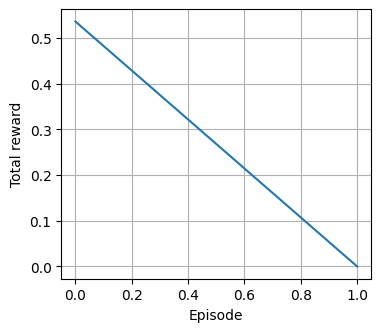

In [9]:
perf.train(num_rounds=10, num_episodes=2)

IHT full, starting to allow collisions


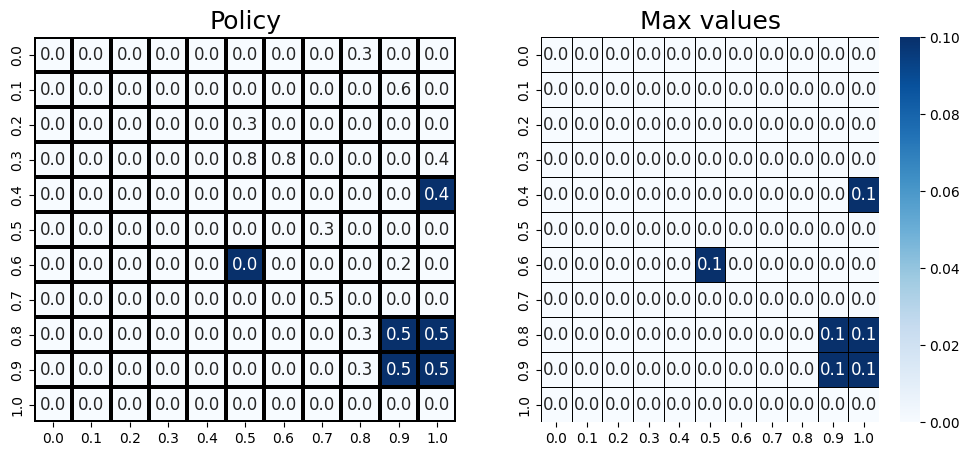

In [10]:
dict_acciones = {i:f"{i/10:.1f}" for i in range(11)}
q_plot = PlotQApprox2D(
    Q=perf.agent.Q,
    state_scales=state_scales, 
    dict_acciones=dict_acciones,
    mesh_size=11,
)
q_plot.best_actions_with_values(max_deci=1)

Loading agent from /Users/edgar/Documents/GitHub/foragers_and_manager_sim_RL/models/QLearningCS_in_DiscreteForagersEnv/QLearningCS_in_DiscreteForagersEnv.json


  0%|          | 0/100 [00:00<?, ?it/s]

===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0. ... 0. 0. 0.]
===> [0. 0. 0.

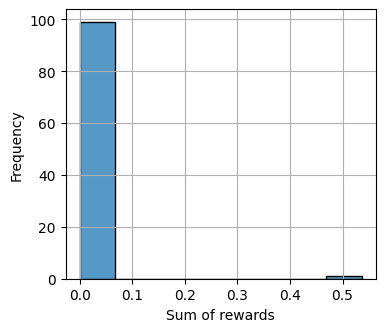

In [11]:
perf.test(num_rounds=500, num_episodes=100)

TypeError: Image data of dtype object cannot be converted to float

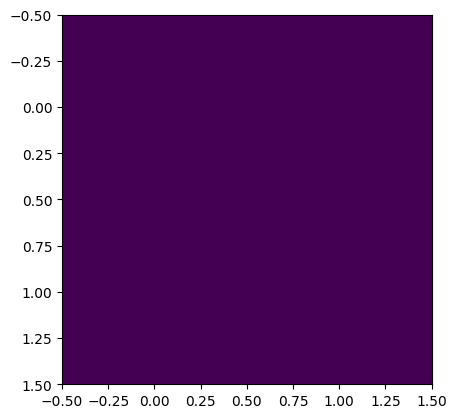

In [12]:
perf.run(from_file=True, no_exploration=True, to_video=True, num_rounds=200)